In [1]:
!pip install -q kagglehub transformers sentence-transformers \
             datasets accelerate xgboost gensim nltk shap \
             wordcloud torch -q

print("✅ Installation done!")

✅ Installation done!


In [2]:
import kagglehub, os, re, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# ── NLTK ─────────────────────────────────────────────────────
import nltk
for pkg in ['punkt','stopwords','wordnet','averaged_perceptron_tagger',
            'omw-1.4','punkt_tab']:
    nltk.download(pkg, quiet=True)

from nltk.corpus   import stopwords
from nltk.stem     import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# ── Sklearn ───────────────────────────────────────────────────
from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing      import LabelEncoder
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, roc_auc_score)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model       import LogisticRegression
from sklearn.naive_bayes        import MultinomialNB
from sklearn.svm                import LinearSVC
from sklearn.calibration        import CalibratedClassifierCV

# ── Gensim ───────────────────────────────────────────────────
from gensim.models import Word2Vec

# ── TensorFlow / Keras ───────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models     import Sequential, Model
from tensorflow.keras.layers     import (Dense, Dropout, LSTM, GRU,
                                          Embedding, Bidirectional,
                                          BatchNormalization, Input,
                                          GlobalMaxPooling1D)
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils      import to_categorical

# ── PyTorch + Transformers ────────────────────────────────────
import torch
import torch.nn.functional as F
from torch.utils.data    import Dataset, DataLoader
from transformers        import (AutoTokenizer,
                                  BertTokenizer,
                                  BertForSequenceClassification,
                                  TrainingArguments, Trainer)
from sentence_transformers import SentenceTransformer

# ── WordCloud ────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    WC = True
except:
    WC = False

print("✅ All imports done!")
print(f"   TensorFlow : {tf.__version__}")
print(f"   PyTorch    : {torch.__version__}")

✅ All imports done!
   TensorFlow : 2.20.0
   PyTorch    : 2.10.0+cu128


In [3]:
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print(" Path:", path)

for root, _, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

📁 Path: /kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis
/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv
/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv


In [4]:
train_path = os.path.join(path, "twitter_training.csv")
val_path   = os.path.join(path, "twitter_validation.csv")

col_names = ['id','entity','sentiment','text']

train_df = pd.read_csv(train_path, header=None, names=col_names)
val_df   = pd.read_csv(val_path,   header=None, names=col_names)

df = pd.concat([train_df, val_df], ignore_index=True)

print("Combined shape :", df.shape)
print("\nSentiment classes:")
print(df['sentiment'].value_counts())
df.head()

Combined shape : (75682, 4)

Sentiment classes:
sentiment
Negative      22808
Positive      21109
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
print("Before cleaning:", df.shape)

# Drop nulls
df.dropna(subset=['text','sentiment'], inplace=True)

# Keep only 3 main classes
df = df[df['sentiment'].isin(['Positive','Negative','Neutral'])]

# Remove duplicates
df.drop_duplicates(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("After  cleaning:", df.shape)
print("\nFinal class distribution:")
print(df['sentiment'].value_counts())

Before cleaning: (75682, 4)
After  cleaning: (57693, 4)

Final class distribution:
sentiment
Negative    21263
Positive    19211
Neutral     17219
Name: count, dtype: int64


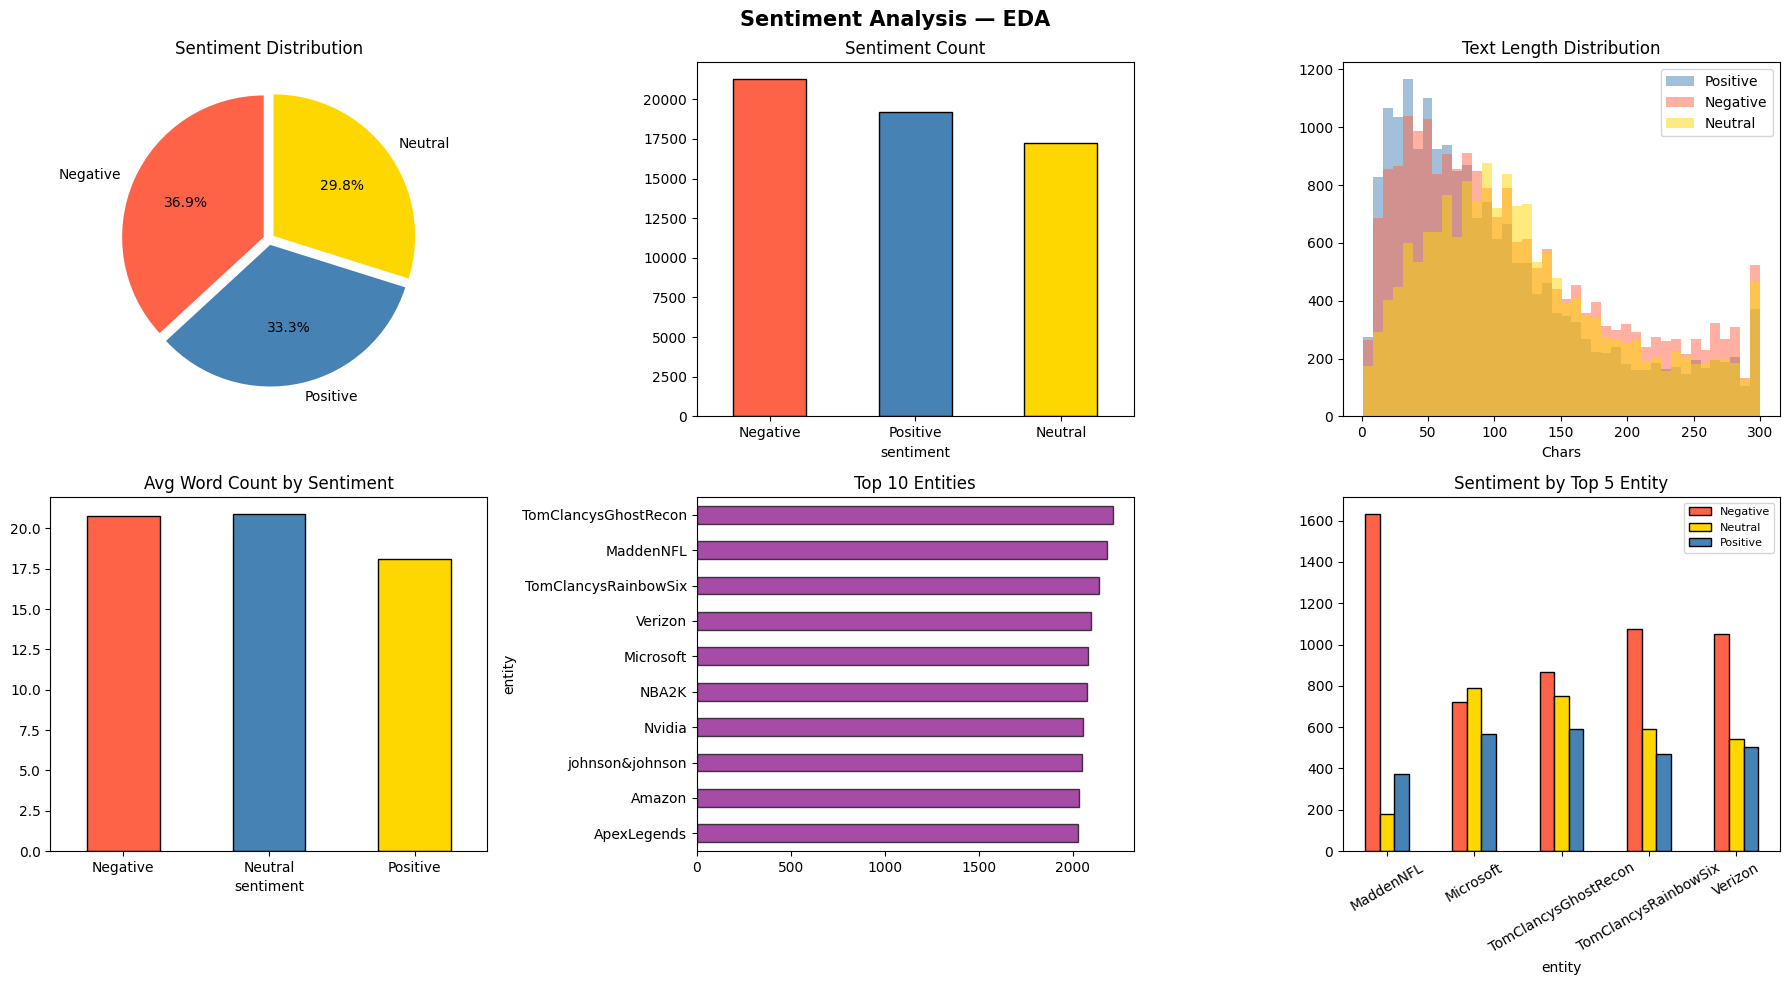

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sentiment Analysis — EDA', fontsize=15, fontweight='bold')

COLORS = {'Positive':'steelblue','Negative':'tomato','Neutral':'gold'}
clr    = [COLORS[s] for s in df['sentiment'].value_counts().index]

# 6a. Class distribution — pie
axes[0,0].pie(df['sentiment'].value_counts(),
              labels  = df['sentiment'].value_counts().index,
              autopct ='%1.1f%%',
              colors  = clr,
              startangle=90, explode=[0.04]*3)
axes[0,0].set_title('Sentiment Distribution')

# 6b. Class distribution — bar
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0,1],
    color=clr, edgecolor='black')
axes[0,1].set_title('Sentiment Count')
axes[0,1].tick_params(axis='x', rotation=0)

# 6c. Text length by sentiment
df['text_len'] = df['text'].astype(str).apply(len)
for sent, color in COLORS.items():
    axes[0,2].hist(df[df['sentiment']==sent]['text_len'].clip(upper=300),
                   bins=40, alpha=0.5, color=color, label=sent)
axes[0,2].set_title('Text Length Distribution')
axes[0,2].set_xlabel('Chars'); axes[0,2].legend()

# 6d. Word count by sentiment
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df.groupby('sentiment')['word_count'].mean().plot(
    kind='bar', ax=axes[1,0], color=clr, edgecolor='black')
axes[1,0].set_title('Avg Word Count by Sentiment')
axes[1,0].tick_params(axis='x', rotation=0)

# 6e. Top entities
df['entity'].value_counts().head(10).plot(
    kind='barh', ax=axes[1,1], color='purple', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Top 10 Entities')
axes[1,1].invert_yaxis()

# 6f. Sentiment by top entity
top5_ent = df['entity'].value_counts().head(5).index
df_top   = df[df['entity'].isin(top5_ent)]
cross_tab= pd.crosstab(df_top['entity'], df_top['sentiment'])
cross_tab.plot(kind='bar', ax=axes[1,2],
               color=['tomato','gold','steelblue'], edgecolor='black')
axes[1,2].set_title('Sentiment by Top 5 Entity')
axes[1,2].tick_params(axis='x', rotation=30)
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
def clean_text(text, stem=False, lemma=True):
    """Full NLP cleaning pipeline."""
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions & hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove HTML
    text = re.sub(r'<.*?>', '', text)
    # Remove special chars / digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Stopword removal
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    # Stemming
    if stem:
        tokens = [stemmer.stem(t) for t in tokens]
    # Lemmatization
    elif lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print(" Cleaning texts...")
df['cleaned']      = df['text'].apply(lambda x: clean_text(x, lemma=True))
df['cleaned_stem'] = df['text'].apply(lambda x: clean_text(x, stem=True))

print(" Done!")
print("\nOriginal :", df['text'].iloc[0])
print("Cleaned  :", df['cleaned'].iloc[0])
print("Stemmed  :", df['cleaned_stem'].iloc[0])

 Cleaning texts...
 Done!

Original : im getting on borderlands and i will murder you all ,
Cleaned  : getting borderland murder
Stemmed  : get borderland murder


In [8]:
sample = df['text'].iloc[2]

print(f"Original  : {sample}")

tokens = word_tokenize(sample.lower())
print(f"\n🔹 Tokenized       : {tokens[:15]}")

no_stop = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
print(f"🔹 Stop Removed    : {no_stop[:15]}")

stemmed = [stemmer.stem(t) for t in no_stop]
print(f"🔹 Stemmed         : {stemmed[:15]}")

lemmatized = [lemmatizer.lemmatize(t) for t in no_stop]
print(f"🔹 Lemmatized      : {lemmatized[:15]}")

Original  : im getting on borderlands and i will kill you all,

🔹 Tokenized       : ['im', 'getting', 'on', 'borderlands', 'and', 'i', 'will', 'kill', 'you', 'all', ',']
🔹 Stop Removed    : ['im', 'getting', 'borderlands', 'kill']
🔹 Stemmed         : ['im', 'get', 'borderland', 'kill']
🔹 Lemmatized      : ['im', 'getting', 'borderland', 'kill']


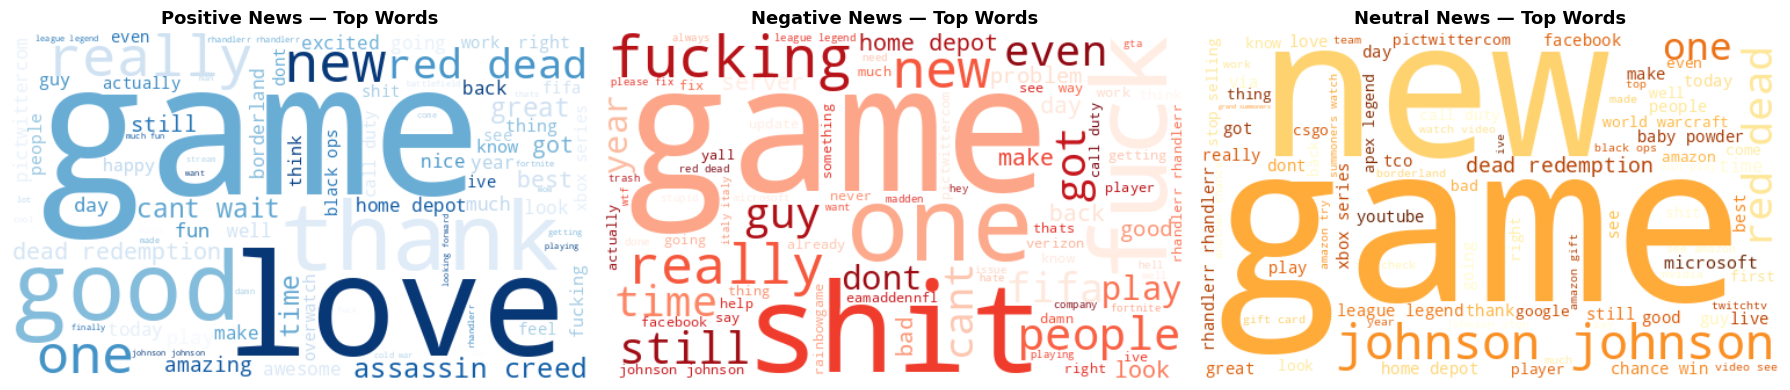

In [9]:
if WC:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sentiments = ['Positive','Negative','Neutral']
    cmaps      = ['Blues','Reds','YlOrBr']

    for ax, sent, cmap in zip(axes, sentiments, cmaps):
        corpus = ' '.join(df[df['sentiment']==sent]['cleaned'].tolist())
        wc = WordCloud(width=500, height=300,
                       background_color='white',
                       colormap=cmap,
                       max_words=80).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{sent} News — Top Words',
                     fontsize=13, fontweight='bold')

    plt.tight_layout(); plt.show()

In [10]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
# Negative=0  Neutral=1  Positive=2

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

NUM_CLASSES = len(le.classes_)
print(f"\nNumber of classes: {NUM_CLASSES}")

X_text = df['cleaned'].values
y      = df['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.1, random_state=42, stratify=y_tr)

print(f"\nTrain : {len(X_tr)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_te)}")

Label mapping:
  0 → Negative
  1 → Neutral
  2 → Positive

Number of classes: 3

Train : 41538
Val   : 4616
Test  : 11539


In [11]:
print(" Building TF-IDF Features...")

tfidf = TfidfVectorizer(
    max_features = 40000,
    ngram_range  = (1, 2),
    min_df       = 2,
    sublinear_tf = True
)

X_tr_tfidf  = tfidf.fit_transform(X_tr)
X_val_tfidf = tfidf.transform(X_val)
X_te_tfidf  = tfidf.transform(X_te)

print(f"TF-IDF shape: {X_tr_tfidf.shape}")
print(f"Sample features: {tfidf.get_feature_names_out()[:15]}")

 Building TF-IDF Features...
TF-IDF shape: (41538, 40000)
Sample features: ['aaa' 'aaa game' 'aaron' 'aaron edward' 'aaron rodgers' 'aat' 'aat try'
 'abandon' 'abandon overwatch' 'abandon penalty' 'abandon sanction'
 'abandoned' 'abandoned game' 'abbott' 'abbxvg']


In [12]:
print(" Building Bag-of-Words Features...")

bow = CountVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_tr_bow  = bow.fit_transform(X_tr)
X_te_bow  = bow.transform(X_te)

print(f"BoW shape: {X_tr_bow.shape}")

 Building Bag-of-Words Features...
BoW shape: (41538, 20000)


In [13]:
results = {}

def evaluate(name, y_true, y_pred, y_prob=None, feat=''):
    acc = accuracy_score(y_true, y_pred)

    # Multi-class AUC
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob,
                                multi_class='ovr', average='macro')
        except:
            auc = 0.0
    else:
        auc = 0.0

    label = f"{name} ({feat})" if feat else name
    results[label] = {'Accuracy': acc, 'ROC-AUC (macro)': auc}

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  ROC-AUC (macro): {auc:.4f}")
    print(classification_report(y_true, y_pred,
          target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return acc, auc


  Logistic Regression (TF-IDF)
  Accuracy       : 0.8491
  ROC-AUC (macro): 0.9512
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87      4253
     Neutral       0.84      0.80      0.82      3444
    Positive       0.85      0.85      0.85      3842

    accuracy                           0.85     11539
   macro avg       0.85      0.85      0.85     11539
weighted avg       0.85      0.85      0.85     11539



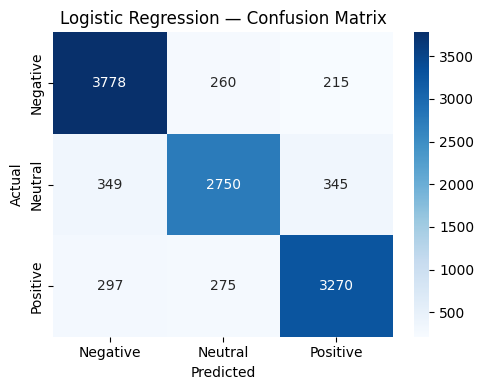


  Logistic Regression (BoW)
  Accuracy       : 0.8516
  ROC-AUC (macro): 0.9579
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.88      4253
     Neutral       0.85      0.79      0.82      3444
    Positive       0.83      0.87      0.85      3842

    accuracy                           0.85     11539
   macro avg       0.85      0.85      0.85     11539
weighted avg       0.85      0.85      0.85     11539



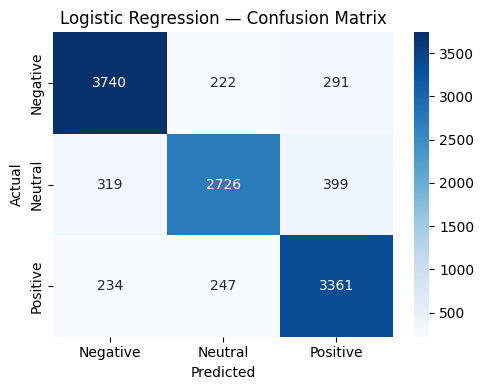

(0.8516335904324465, np.float64(0.9579454725493384))

In [14]:
# TF-IDF
lr = LogisticRegression(max_iter=1000, C=1.0,
                         solver='lbfgs',
                         multi_class='multinomial',
                         random_state=42)
lr.fit(X_tr_tfidf, y_tr)
lr_pred = lr.predict(X_te_tfidf)
lr_prob = lr.predict_proba(X_te_tfidf)
evaluate('Logistic Regression', y_te, lr_pred, lr_prob, 'TF-IDF')

# BoW
lr_bow_m = LogisticRegression(max_iter=1000, solver='lbfgs',
                               multi_class='multinomial', random_state=42)
lr_bow_m.fit(X_tr_bow, y_tr)
lr_bow_pred = lr_bow_m.predict(X_te_bow)
lr_bow_prob = lr_bow_m.predict_proba(X_te_bow)
evaluate('Logistic Regression', y_te, lr_bow_pred, lr_bow_prob, 'BoW')


  Naive Bayes (TF-IDF)
  Accuracy       : 0.8373
  ROC-AUC (macro): 0.9546
              precision    recall  f1-score   support

    Negative       0.82      0.90      0.86      4253
     Neutral       0.87      0.75      0.80      3444
    Positive       0.83      0.85      0.84      3842

    accuracy                           0.84     11539
   macro avg       0.84      0.83      0.83     11539
weighted avg       0.84      0.84      0.84     11539



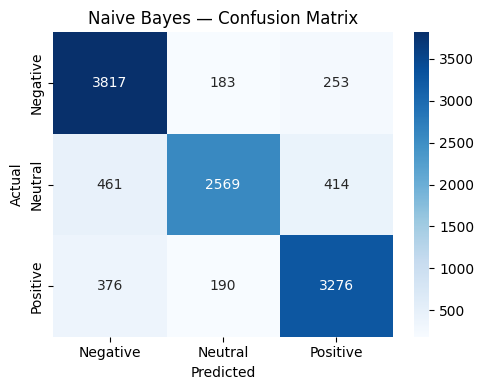

(0.8373342577346391, np.float64(0.9546228680010119))

In [15]:
nb = MultinomialNB(alpha=0.5)
nb.fit(abs(X_tr_tfidf), y_tr)
nb_pred = nb.predict(abs(X_te_tfidf))
nb_prob = nb.predict_proba(abs(X_te_tfidf))
evaluate('Naive Bayes', y_te, nb_pred, nb_prob, 'TF-IDF')


  SVM (TF-IDF)
  Accuracy       : 0.8948
  ROC-AUC (macro): 0.9726
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91      4253
     Neutral       0.87      0.88      0.88      3444
    Positive       0.90      0.89      0.90      3842

    accuracy                           0.89     11539
   macro avg       0.89      0.89      0.89     11539
weighted avg       0.89      0.89      0.89     11539



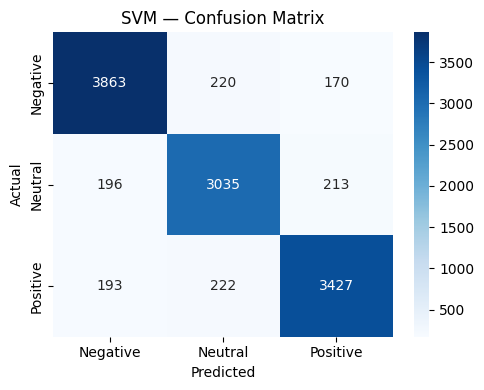

(0.8947915763931017, np.float64(0.9725647953830068))

In [16]:
# CalibratedClassifierCV gives predict_proba for LinearSVC
svm_base = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm      = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_tr_tfidf, y_tr)
svm_pred = svm.predict(X_te_tfidf)
svm_prob = svm.predict_proba(X_te_tfidf)
evaluate('SVM', y_te, svm_pred, svm_prob, 'TF-IDF')

 Training Word2Vec...
Vocab size: 17140
  Similar to 'good': [('sad', 0.5493857860565186), ('satisfying', 0.5348688960075378), ('nice', 0.5138151049613953)]
  Similar to 'bad': [('sad', 0.5715323090553284), ('stupid', 0.5589408874511719), ('stingy', 0.558440625667572)]
  Similar to 'happy': [('appreciate', 0.6303632855415344), ('valkyrie', 0.6187304258346558), ('birthday', 0.5847309231758118)]
Word2Vec feature shape: (41538, 100)

  Logistic Regression (Word2Vec)
  Accuracy       : 0.6251
  ROC-AUC (macro): 0.7943
              precision    recall  f1-score   support

    Negative       0.66      0.71      0.68      4253
     Neutral       0.57      0.53      0.55      3444
    Positive       0.64      0.62      0.63      3842

    accuracy                           0.63     11539
   macro avg       0.62      0.62      0.62     11539
weighted avg       0.62      0.63      0.62     11539



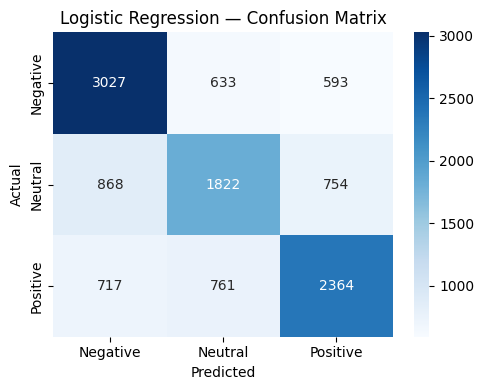

(0.6250974954502123, np.float64(0.7942520178690549))

In [17]:
print(" Training Word2Vec...")

train_tokens = [t.split() for t in X_tr]

w2v = Word2Vec(sentences   = train_tokens,
               vector_size = 100,
               window      = 5,
               min_count   = 2,
               workers     = 4,
               epochs      = 15)

print(f"Vocab size: {len(w2v.wv)}")

# Similarity demo
for word in ['good','bad','happy']:
    try:
        sim = w2v.wv.most_similar(word, topn=3)
        print(f"  Similar to '{word}': {sim}")
    except:
        pass

def avg_w2v(text, model, size=100):
    words = text.split()
    vecs  = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_tr_w2v = np.array([avg_w2v(t, w2v) for t in X_tr])
X_te_w2v = np.array([avg_w2v(t, w2v) for t in X_te])

print(f"Word2Vec feature shape: {X_tr_w2v.shape}")

# LR on Word2Vec
lr_w2v = LogisticRegression(max_iter=1000, multi_class='multinomial',
                              random_state=42)
lr_w2v.fit(X_tr_w2v, y_tr)
w2v_pred = lr_w2v.predict(X_te_w2v)
w2v_prob = lr_w2v.predict_proba(X_te_w2v)
evaluate('Logistic Regression', y_te, w2v_pred, w2v_prob, 'Word2Vec')

 Loading GloVe...
 GloVe downloaded!
 GloVe loaded! Vocab: 400000
GloVe feature shape: (41538, 100)

  Logistic Regression (GloVe)
  Accuracy       : 0.5940
  ROC-AUC (macro): 0.7670
              precision    recall  f1-score   support

    Negative       0.62      0.70      0.66      4253
     Neutral       0.53      0.43      0.48      3444
    Positive       0.60      0.62      0.61      3842

    accuracy                           0.59     11539
   macro avg       0.59      0.58      0.58     11539
weighted avg       0.59      0.59      0.59     11539



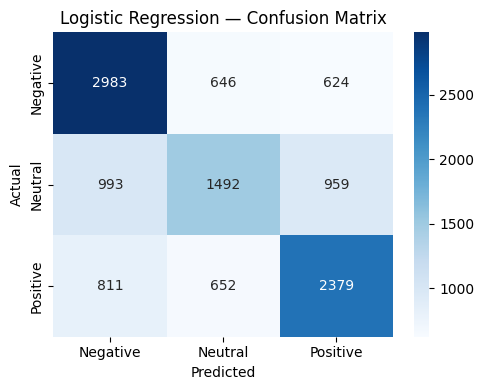

(0.5939856140046798, np.float64(0.7670426593475095))

In [18]:
print(" Loading GloVe...")

GLOVE_PATH = 'glove.6B.100d.txt'

if not os.path.exists(GLOVE_PATH):
    import urllib.request, zipfile
    try:
        print("Downloading GloVe 6B...")
        urllib.request.urlretrieve(
            "http://nlp.stanford.edu/data/glove.6B.zip", "glove.6B.zip")
        with zipfile.ZipFile("glove.6B.zip") as z:
            z.extract("glove.6B.100d.txt", ".")
        print(" GloVe downloaded!")
    except Exception as e:
        print(f" Download failed ({e}) — using Word2Vec as fallback")
        GLOVE_PATH = None

glove = {}
if GLOVE_PATH and os.path.exists(GLOVE_PATH):
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
    print(f" GloVe loaded! Vocab: {len(glove)}")
else:
    glove = {w: w2v.wv[w] for w in w2v.wv.key_to_index}
    print("Using Word2Vec vectors as GloVe substitute")

def avg_glove(text, glove_dict, size=100):
    words = text.split()
    vecs  = [glove_dict[w] for w in words if w in glove_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_tr_glove = np.array([avg_glove(t, glove) for t in X_tr])
X_te_glove = np.array([avg_glove(t, glove) for t in X_te])

print(f"GloVe feature shape: {X_tr_glove.shape}")

# LR on GloVe
lr_glove = LogisticRegression(max_iter=1000, multi_class='multinomial',
                               random_state=42)
lr_glove.fit(X_tr_glove, y_tr)
glv_pred = lr_glove.predict(X_te_glove)
glv_prob = lr_glove.predict_proba(X_te_glove)
evaluate('Logistic Regression', y_te, glv_pred, glv_prob, 'GloVe')

In [19]:
MAX_VOCAB = 30000
MAX_LEN   = 100
EMB_DIM   = 100

keras_tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tok.fit_on_texts(X_tr)

def encode(texts):
    seqs = keras_tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN,
                         padding='post', truncating='post')

X_tr_pad  = encode(X_tr)
X_val_pad = encode(X_val)
X_te_pad  = encode(X_te)

print(f"Padded shape — Train: {X_tr_pad.shape}  Test: {X_te_pad.shape}")

# GloVe Embedding Matrix
word_index  = keras_tok.word_index
vocab_size  = min(MAX_VOCAB, len(word_index)) + 1
emb_matrix  = np.zeros((vocab_size, EMB_DIM))

for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = glove.get(word)
    if vec is not None:
        emb_matrix[idx] = vec

print(f"Embedding matrix: {emb_matrix.shape}")

# One-hot labels for Keras
y_tr_cat  = to_categorical(y_tr,  NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_te_cat  = to_categorical(y_te,  NUM_CLASSES)

Padded shape — Train: (41538, 100)  Test: (11539, 100)
Embedding matrix: (25908, 100)


 Building ANN...


I0000 00:00:1783275188.433032      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783275188.436044      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    20,480,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,648,195 (78.77 MB)

 Trainable params: 20,646,659 (78.76 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/30
 16/650 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3360 - loss: 1.5374

I0000 00:00:1783275209.844432     319 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


650/650 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.7584 - loss: 0.5844 - val_accuracy: 0.8852 - val_loss: 0.3529 - learning_rate: 0.0010
Epoch 2/30
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9318 - loss: 0.1878 - val_accuracy: 0.8969 - val_loss: 0.2813 - learning_rate: 0.0010
Epoch 3/30
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9512 - loss: 0.1306 - val_accuracy: 0.9036 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 4/30
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9592 - loss: 0.1078 - val_accuracy: 0.9006 - val_loss: 0.2849 - learning_rate: 0.0010
Epoch 5/30
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9643 - loss: 0.0899 - val_accuracy: 0.9060 - val_loss: 0.3092 - learning_rate: 0.0010
Epoch 6/30
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9662 - loss: 0.0877 - val_accuracy: 0.9045 - val_loss: 0.3208 - learning_rate: 0.0010
Epoch 7/30
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9730 - loss: 0.0670 - val

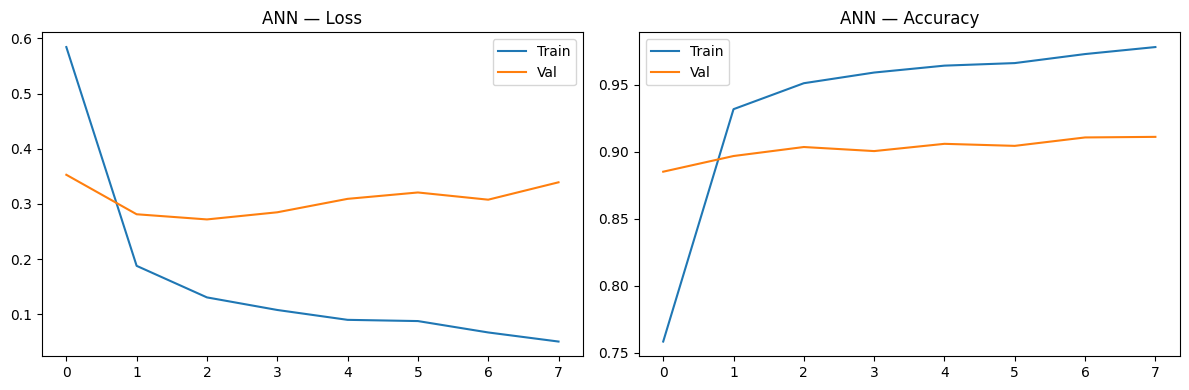


  ANN (TF-IDF)
  Accuracy       : 0.9042
  ROC-AUC (macro): 0.9813
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.92      4253
     Neutral       0.89      0.90      0.90      3444
    Positive       0.88      0.91      0.90      3842

    accuracy                           0.90     11539
   macro avg       0.90      0.90      0.90     11539
weighted avg       0.90      0.90      0.90     11539



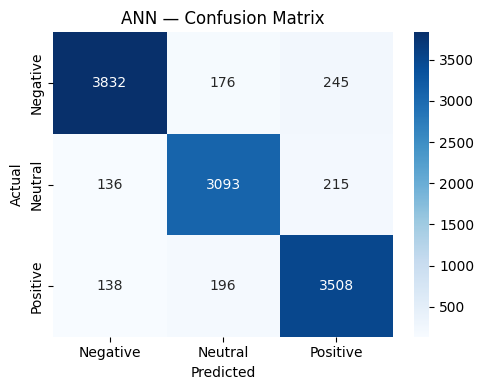

(0.9041511396134847, np.float64(0.9813179512883826))

In [20]:
print(" Building ANN...")

# ANN uses TF-IDF dense features (convert sparse → dense)
X_tr_tfidf_dense  = X_tr_tfidf.toarray().astype(np.float32)
X_val_tfidf_dense = X_val_tfidf.toarray().astype(np.float32)
X_te_tfidf_dense  = X_te_tfidf.toarray().astype(np.float32)

ann = Sequential([
    Dense(512, activation='relu',
          input_dim=X_tr_tfidf_dense.shape[1]),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

ann.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])
ann.summary()

es1  = EarlyStopping(patience=5, restore_best_weights=True, verbose=0)
rlr1 = ReduceLROnPlateau(patience=3, factor=0.5, verbose=0)

h_ann = ann.fit(
    X_tr_tfidf_dense, y_tr_cat,
    validation_data = (X_val_tfidf_dense, y_val_cat),
    epochs=30, batch_size=64,
    callbacks=[es1, rlr1], verbose=1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_ann.history['loss'],     label='Train')
axes[0].plot(h_ann.history['val_loss'], label='Val')
axes[0].set_title('ANN — Loss'); axes[0].legend()
axes[1].plot(h_ann.history['accuracy'],     label='Train')
axes[1].plot(h_ann.history['val_accuracy'], label='Val')
axes[1].set_title('ANN — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

ann_prob = ann.predict(X_te_tfidf_dense, verbose=0)
ann_pred = np.argmax(ann_prob, axis=1)
evaluate('ANN', y_te, ann_pred, ann_prob, 'TF-IDF')

 Building BiLSTM...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,590,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,800 (9.88 MB)

 Trainable params: 2,590,800 (9.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.6018 - loss: 0.8758 - val_accuracy: 0.6958 - val_loss: 0.7215 - learning_rate: 0.0010
Epoch 2/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7263 - loss: 0.6698 - val_accuracy: 0.7693 - val_loss: 0.5774 - learning_rate: 0.0010
Epoch 3/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8074 - loss: 0.5010 - val_accuracy: 0.8232 - val_loss: 0.4628 - learning_rate: 0.0010
Epoch 4/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8621 - loss: 0.3688 - val_accuracy: 0.8427 - val_loss: 0.4087 - learning_rate: 0.0010
Epoch 5/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8927 - loss: 0.2897 - val_accuracy: 0.8640 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 6/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9111 - loss: 0.2401 - val_accuracy: 0.8763 - val_loss: 0.3532 - learning_rate: 0.0010
Epoch 7/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9222 - l

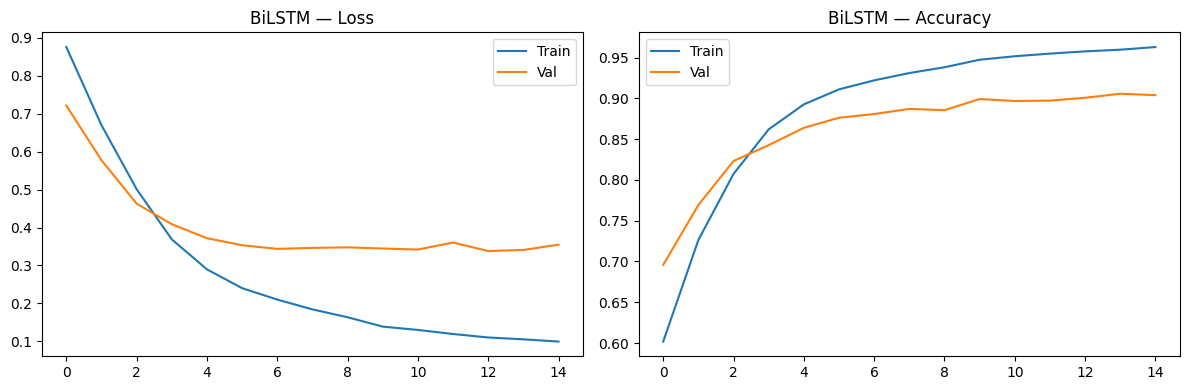


  BiLSTM (GloVe Emb)
  Accuracy       : 0.9021
  ROC-AUC (macro): 0.9773
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.91      4253
     Neutral       0.91      0.89      0.90      3444
    Positive       0.87      0.92      0.90      3842

    accuracy                           0.90     11539
   macro avg       0.90      0.90      0.90     11539
weighted avg       0.90      0.90      0.90     11539



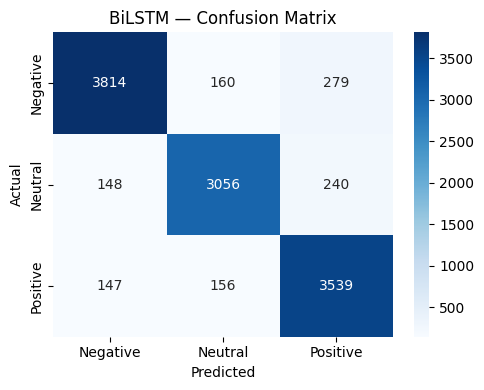

(0.9020712366756218, np.float64(0.9772835096077671))

In [21]:
print(" Building BiLSTM...")

def build_lstm(vocab_size, emb_dim, max_len, emb_matrix, num_classes):
    model = Sequential([
        Embedding(vocab_size, emb_dim,
                  weights=[emb_matrix],
                  input_length=max_len,
                  trainable=True),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
        Bidirectional(LSTM(64,  dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm(vocab_size, EMB_DIM, MAX_LEN,
                         emb_matrix, NUM_CLASSES)
lstm_model.summary()

es2  = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
rlr2 = ReduceLROnPlateau(patience=2, factor=0.5, verbose=0)

h_lstm = lstm_model.fit(
    X_tr_pad, y_tr_cat,
    validation_data = (X_val_pad, y_val_cat),
    epochs=15, batch_size=128,
    callbacks=[es2, rlr2], verbose=1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_lstm.history['loss'],     label='Train')
axes[0].plot(h_lstm.history['val_loss'], label='Val')
axes[0].set_title('BiLSTM — Loss'); axes[0].legend()
axes[1].plot(h_lstm.history['accuracy'],     label='Train')
axes[1].plot(h_lstm.history['val_accuracy'], label='Val')
axes[1].set_title('BiLSTM — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

lstm_prob = lstm_model.predict(X_te_pad, verbose=0)
lstm_pred = np.argmax(lstm_prob, axis=1)
evaluate('BiLSTM', y_te, lstm_pred, lstm_prob, 'GloVe Emb')

 Building BiGRU...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,590,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,800 (9.88 MB)

 Trainable params: 2,590,800 (9.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.5882 - loss: 0.8923 - val_accuracy: 0.6948 - val_loss: 0.7182 - learning_rate: 0.0010
Epoch 2/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7271 - loss: 0.6647 - val_accuracy: 0.7790 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 3/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8178 - loss: 0.4749 - val_accuracy: 0.8237 - val_loss: 0.4627 - learning_rate: 0.0010
Epoch 4/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8702 - loss: 0.3448 - val_accuracy: 0.8473 - val_loss: 0.3890 - learning_rate: 0.0010
Epoch 5/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8972 - loss: 0.2704 - val_accuracy: 0.8666 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 6/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9158 - loss: 0.2271 - val_accuracy: 0.8754 - val_loss: 0.3452 - learning_rate: 0.0010
Epoch 7/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9274 - l

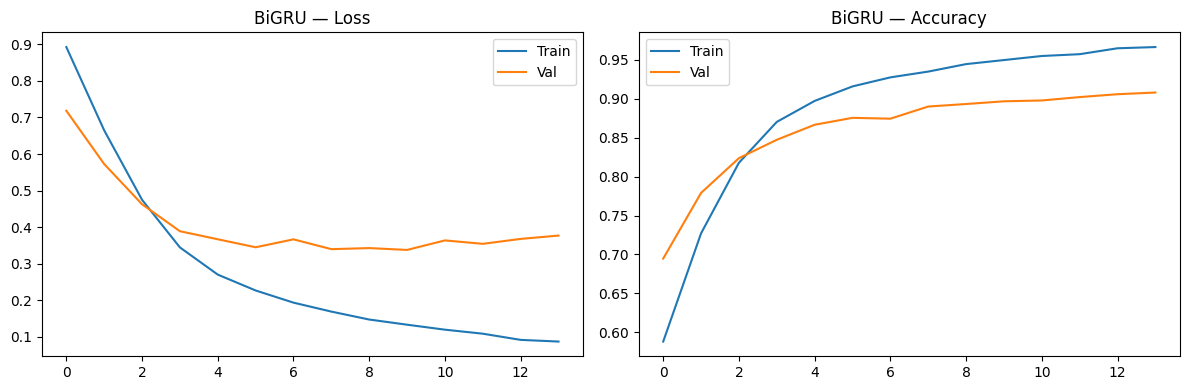


  BiGRU (GloVe Emb)
  Accuracy       : 0.8965
  ROC-AUC (macro): 0.9766
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      4253
     Neutral       0.91      0.88      0.89      3444
    Positive       0.86      0.92      0.89      3842

    accuracy                           0.90     11539
   macro avg       0.90      0.90      0.90     11539
weighted avg       0.90      0.90      0.90     11539



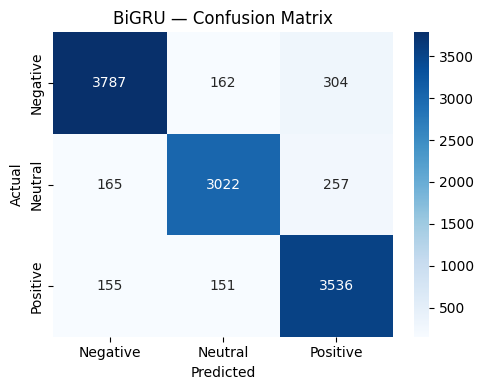

(0.8965248288413208, np.float64(0.976610095969689))

In [22]:
print(" Building BiGRU...")

def build_gru(vocab_size, emb_dim, max_len, emb_matrix, num_classes):
    model = Sequential([
        Embedding(vocab_size, emb_dim,
                  weights=[emb_matrix],
                  input_length=max_len,
                  trainable=True),
        Bidirectional(GRU(128, return_sequences=True, dropout=0.3)),
        Bidirectional(GRU(64,  dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

gru_model = build_gru(vocab_size, EMB_DIM, MAX_LEN,
                       emb_matrix, NUM_CLASSES)
gru_model.summary()

es3  = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
rlr3 = ReduceLROnPlateau(patience=2, factor=0.5, verbose=0)

h_gru = gru_model.fit(
    X_tr_pad, y_tr_cat,
    validation_data = (X_val_pad, y_val_cat),
    epochs=15, batch_size=128,
    callbacks=[es3, rlr3], verbose=1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_gru.history['loss'],     label='Train')
axes[0].plot(h_gru.history['val_loss'], label='Val')
axes[0].set_title('BiGRU — Loss'); axes[0].legend()
axes[1].plot(h_gru.history['accuracy'],     label='Train')
axes[1].plot(h_gru.history['val_accuracy'], label='Val')
axes[1].set_title('BiGRU — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

gru_prob = gru_model.predict(X_te_pad, verbose=0)
gru_pred = np.argmax(gru_prob, axis=1)
evaluate('BiGRU', y_te, gru_pred, gru_prob, 'GloVe Emb')

In [23]:
print(" BERT Fine-tuning (Multi-Class)...")

import transformers
print(f"Transformers version: {transformers.__version__}")

BERT_MODEL  = 'bert-base-uncased'
BERT_MAX    = 128
BERT_BATCH  = 16
BERT_EPOCHS = 3
BERT_TRAIN  = 4000
BERT_TEST   = 1000

idx_tr_b = np.random.choice(len(X_tr), BERT_TRAIN, replace=False)
idx_te_b = np.random.choice(len(X_te), BERT_TEST,  replace=False)

bert_tr_texts  = X_tr[idx_tr_b].tolist()
bert_tr_labels = y_tr[idx_tr_b].tolist()
bert_te_texts  = X_te[idx_te_b].tolist()
bert_te_labels = y_te[idx_te_b].tolist()

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

 BERT Fine-tuning (Multi-Class)...
Transformers version: 5.0.0


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [24]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

bert_tr_ds = SentimentDataset(bert_tr_texts, bert_tr_labels,
                               bert_tokenizer, BERT_MAX)
bert_te_ds = SentimentDataset(bert_te_texts,  bert_te_labels,
                               bert_tokenizer, BERT_MAX)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels             = NUM_CLASSES,
    ignore_mismatched_sizes= True
)
bert_model = bert_model.to(device)

Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
bert_args = TrainingArguments(
    output_dir                  = './bert_sentiment',
    num_train_epochs            = BERT_EPOCHS,
    per_device_train_batch_size = BERT_BATCH,
    per_device_eval_batch_size  = BERT_BATCH,
    eval_strategy               = 'epoch',      
    save_strategy               = 'no',
    logging_steps               = 50,
    load_best_model_at_end      = False,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
    warmup_steps                = 100,
    weight_decay                = 0.01,
)

bert_trainer = Trainer(
    model         = bert_model,
    args          = bert_args,
    train_dataset = bert_tr_ds,
    eval_dataset  = bert_te_ds,
)

print(" BERT Training started...")
bert_trainer.train()

 BERT Training started...


Epoch,Training Loss,Validation Loss
1,1.854777,1.752519
2,1.360926,1.560652
3,0.829803,1.731631


TrainOutput(global_step=375, training_loss=1.4032229258219402, metrics={'train_runtime': 187.4607, 'train_samples_per_second': 64.013, 'train_steps_per_second': 2.0, 'total_flos': 789340253184000.0, 'train_loss': 1.4032229258219402, 'epoch': 3.0})


  BERT (Fine-tuned)
  Accuracy       : 0.6920
  ROC-AUC (macro): 0.8359
              precision    recall  f1-score   support

    Negative       0.69      0.77      0.73       339
     Neutral       0.64      0.54      0.59       301
    Positive       0.73      0.74      0.74       360

    accuracy                           0.69      1000
   macro avg       0.69      0.69      0.68      1000
weighted avg       0.69      0.69      0.69      1000



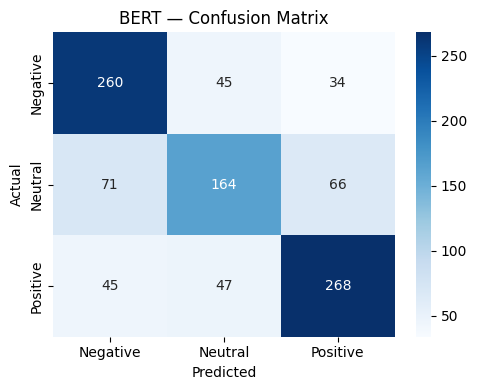

(0.692, np.float64(0.8358659121396089))

In [26]:
bert_out   = bert_trainer.predict(bert_te_ds)
bert_logits= bert_out.predictions
bert_prob  = F.softmax(torch.tensor(bert_logits), dim=1).numpy()
bert_pred  = np.argmax(bert_logits, axis=1)
bert_true  = np.array(bert_te_labels)

evaluate('BERT', bert_true, bert_pred, bert_prob, 'Fine-tuned')

 Sentence Transformers (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding train...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Encoding test...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

ST embedding shape: (6000, 384)

  Sentence Transformer + LR (MiniLM-L6-v2)
  Accuracy       : 0.6393
  ROC-AUC (macro): 0.8063
              precision    recall  f1-score   support

    Negative       0.64      0.75      0.69       541
     Neutral       0.57      0.46      0.51       436
    Positive       0.68      0.68      0.68       523

    accuracy                           0.64      1500
   macro avg       0.63      0.63      0.63      1500
weighted avg       0.64      0.64      0.63      1500



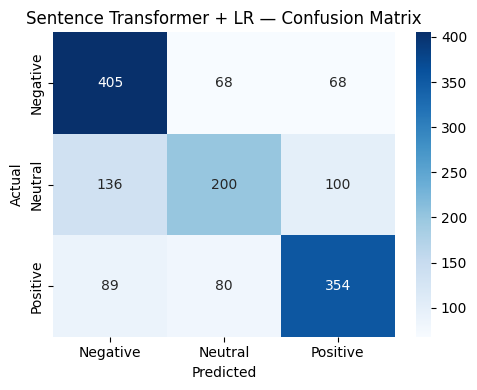

(0.6393333333333333, np.float64(0.8062757049913604))

In [27]:
print(" Sentence Transformers (all-MiniLM-L6-v2)...")

ST_TRAIN = 6000
ST_TEST  = 1500

idx_st_tr = np.random.choice(len(X_tr), ST_TRAIN, replace=False)
idx_st_te = np.random.choice(len(X_te), ST_TEST,  replace=False)

st_tr_texts  = X_tr[idx_st_tr].tolist()
st_tr_labels = y_tr[idx_st_tr]
st_te_texts  = X_te[idx_st_te].tolist()
st_te_labels = y_te[idx_st_te]

st_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding train...")
st_tr_emb = st_model.encode(st_tr_texts, batch_size=64,
                              show_progress_bar=True)
print("Encoding test...")
st_te_emb = st_model.encode(st_te_texts, batch_size=64,
                              show_progress_bar=True)

print(f"ST embedding shape: {st_tr_emb.shape}")

# LR on top of Sentence Transformer
lr_st = LogisticRegression(max_iter=1000, multi_class='multinomial',
                            random_state=42)
lr_st.fit(st_tr_emb, st_tr_labels)

st_pred = lr_st.predict(st_te_emb)
st_prob = lr_st.predict_proba(st_te_emb)

evaluate('Sentence Transformer + LR', st_te_labels,
         st_pred, st_prob, 'MiniLM-L6-v2')

 5-Fold Stratified Cross-Validation...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

  Logistic Regression       0.8543 ± 0.0028
  Naive Bayes               0.8647 ± 0.0027
  SVM                       0.9010 ± 0.0023


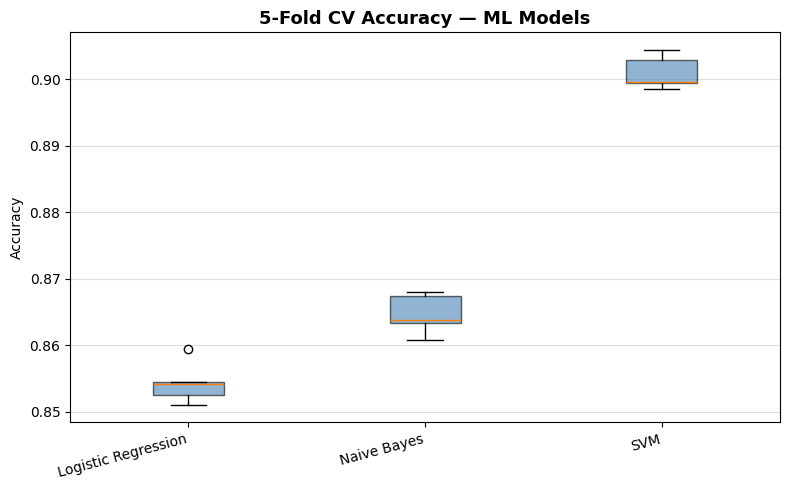

In [28]:
print(" 5-Fold Stratified Cross-Validation...")

cv_models = {
    'Logistic Regression' : lr,
    'Naive Bayes'         : nb,
    'SVM'                 : svm,
}

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in cv_models.items():
    scores = cross_val_score(model,
                             abs(X_tr_tfidf),
                             y_tr,
                             cv=skf,
                             scoring='accuracy',
                             n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(),
            labels=cv_results.keys(),
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.xticks(rotation=15, ha='right')
plt.ylabel('Accuracy')
plt.title('5-Fold CV Accuracy — ML Models',
          fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

Top Discriminative Words per Class (TF-IDF + LR)...


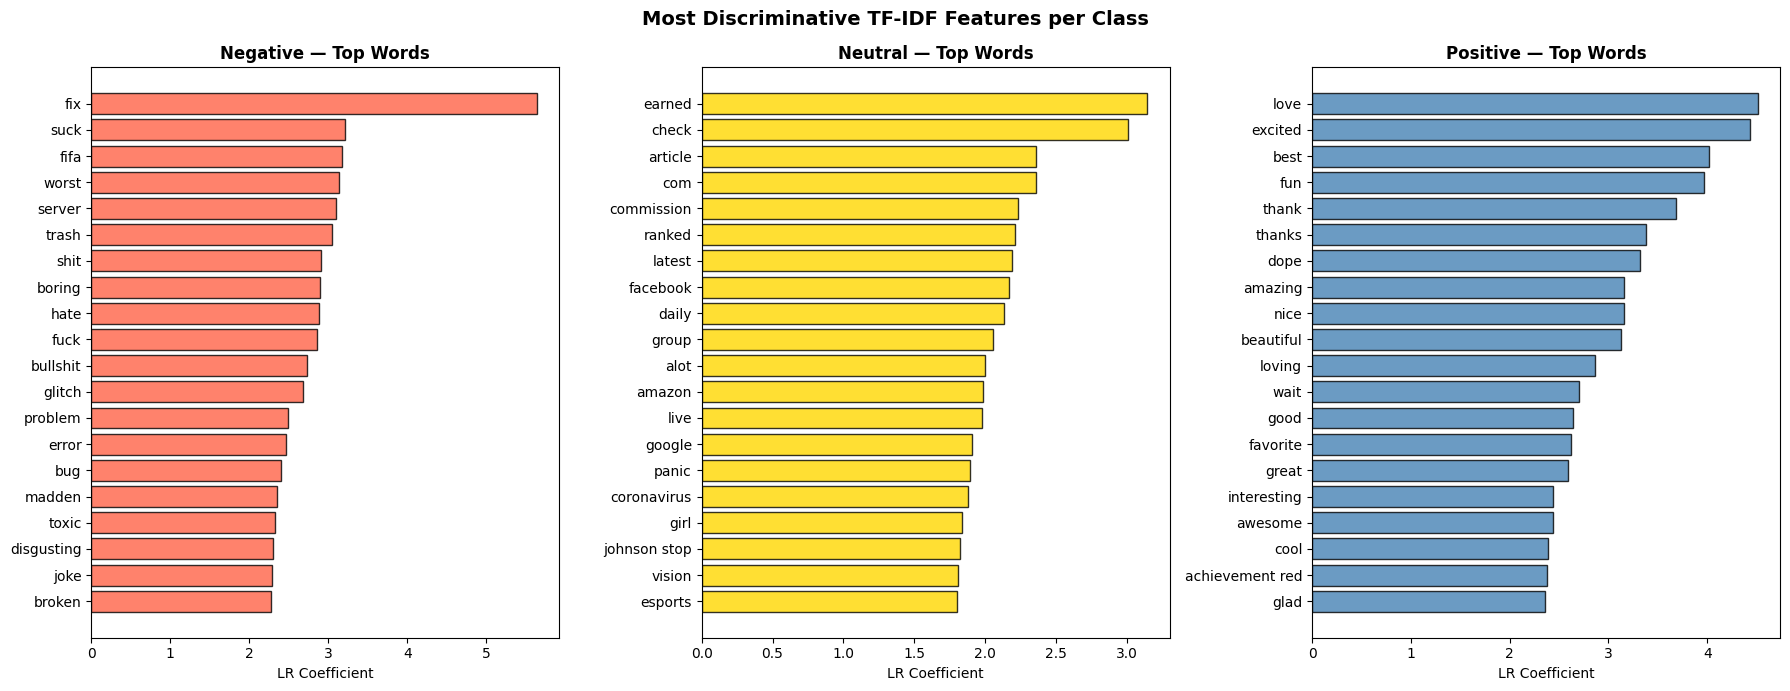

In [29]:
print("Top Discriminative Words per Class (TF-IDF + LR)...")

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 7))
feature_names_arr = tfidf.get_feature_names_out()
colors_map = ['tomato','gold','steelblue']

for i, (cls, color) in enumerate(zip(le.classes_, colors_map)):
    coef   = lr.coef_[i]
    top_idx= coef.argsort()[-20:][::-1]
    words  = [feature_names_arr[j] for j in top_idx]
    vals   = [coef[j] for j in top_idx]

    axes[i].barh(words, vals, color=color, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{cls} — Top Words',
                      fontsize=12, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].set_xlabel('LR Coefficient')

plt.suptitle('Most Discriminative TF-IDF Features per Class',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


 Full Model Comparison:
                                          Accuracy  ROC-AUC (macro)
ANN (TF-IDF)                              0.904151         0.981318
BiLSTM (GloVe Emb)                        0.902071         0.977284
BiGRU (GloVe Emb)                         0.896525         0.976610
SVM (TF-IDF)                              0.894792         0.972565
Logistic Regression (BoW)                 0.851634         0.957945
Logistic Regression (TF-IDF)              0.849120         0.951206
Naive Bayes (TF-IDF)                      0.837334         0.954623
BERT (Fine-tuned)                         0.692000         0.835866
Sentence Transformer + LR (MiniLM-L6-v2)  0.639333         0.806276
Logistic Regression (Word2Vec)            0.625097         0.794252
Logistic Regression (GloVe)               0.593986         0.767043


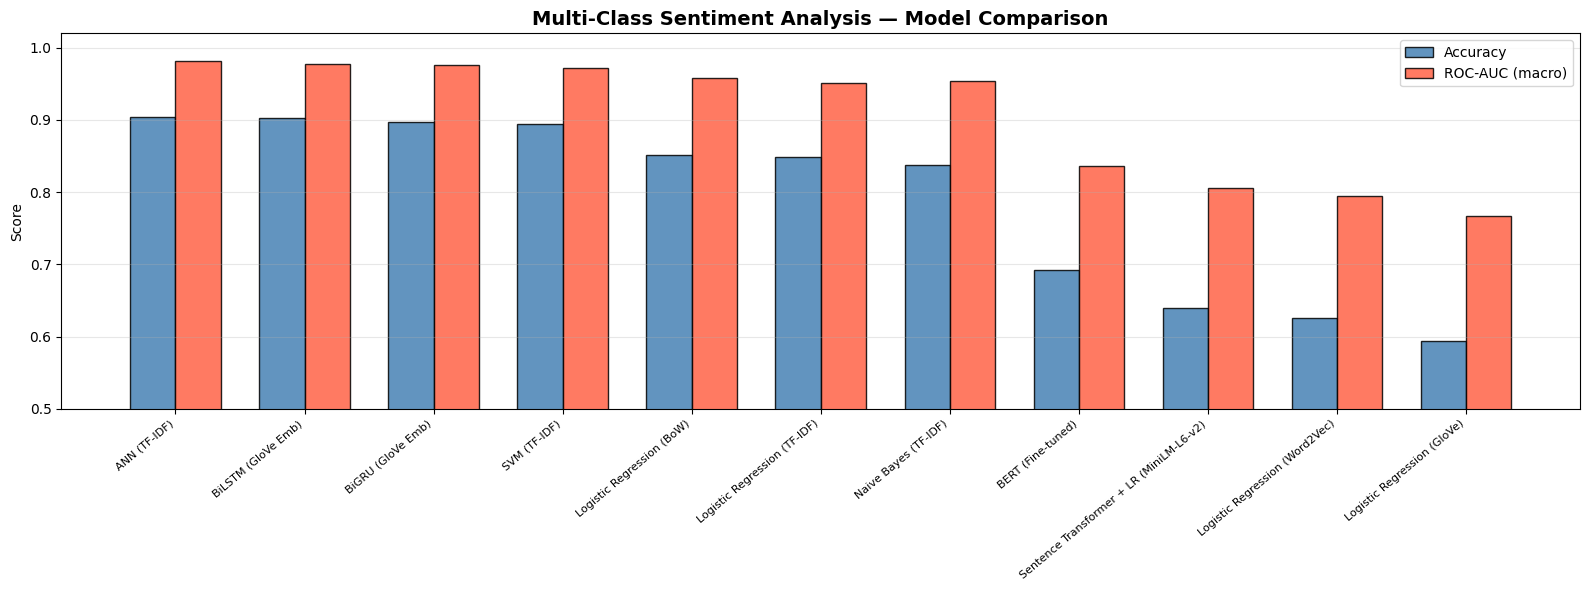

In [30]:
results_df = (pd.DataFrame(results).T
               .sort_values('Accuracy', ascending=False))

print("\n Full Model Comparison:")
print("="*60)
print(results_df.to_string())

# Grouped bar
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df['Accuracy'],
       width=w, label='Accuracy',
       color='steelblue', edgecolor='black', alpha=0.85)
ax.bar(x + w/2, results_df['ROC-AUC (macro)'],
       width=w, label='ROC-AUC (macro)',
       color='tomato', edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index,
                   rotation=40, ha='right', fontsize=8)
ax.set_ylim(0.50, 1.02)
ax.set_ylabel('Score')
ax.set_title('Multi-Class Sentiment Analysis — Model Comparison',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [31]:
print(" LIVE SENTIMENT PREDICTION DEMO")

def predict_sentiment(text, tfidf_vec, lr_model,
                      lstm_mdl, gru_mdl, keras_tok_,
                      max_len_=100):
    cleaned = clean_text(text)

    # TF-IDF + LR
    feat   = tfidf_vec.transform([cleaned])
    lr_p   = lr_model.predict_proba(feat)[0]

    # LSTM
    seq    = keras_tok_.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len_, padding='post')
    lstm_p = lstm_mdl.predict(padded, verbose=0)[0]
    gru_p  = gru_mdl.predict(padded, verbose=0)[0]

    # Ensemble avg
    avg_p  = (lr_p + lstm_p + gru_p) / 3
    pred   = le.classes_[np.argmax(avg_p)]
    conf   = np.max(avg_p)

    emoji  = {'Positive':'😊','Negative':'😠','Neutral':'😐'}
    print(f"\nText      : {text[:100]}")
    print(f"Cleaned   : {cleaned[:100]}")
    print(f"\nLR Probs  : {dict(zip(le.classes_, lr_p.round(3)))}")
    print(f"LSTM Probs: {dict(zip(le.classes_, lstm_p.round(3)))}")
    print(f"GRU Probs : {dict(zip(le.classes_, gru_p.round(3)))}")
    print(f"Ensemble  : {dict(zip(le.classes_, avg_p.round(3)))}")
    print(f"\n→ Prediction : {emoji.get(pred,'')} {pred}  "
          f"(Confidence: {conf*100:.1f}%)")

# Test cases
tests = [
    "I absolutely love this product! It's amazing and works perfectly!",
    "This is terrible. Worst experience I've ever had. Total waste of money.",
    "The product arrived today. It is what I ordered.",
    "Feeling so happy and excited about the new update!",
    "I hate this so much, complete disaster and disappointment."
]

for t in tests:
    print("\n" + "-"*55)
    predict_sentiment(t, tfidf, lr, lstm_model, gru_model, keras_tok)

 LIVE SENTIMENT PREDICTION DEMO

-------------------------------------------------------

Text      : I absolutely love this product! It's amazing and works perfectly!
Cleaned   : absolutely love product amazing work perfectly

LR Probs  : {'Negative': np.float64(0.018), 'Neutral': np.float64(0.092), 'Positive': np.float64(0.89)}
LSTM Probs: {'Negative': np.float32(0.001), 'Neutral': np.float32(0.211), 'Positive': np.float32(0.788)}
GRU Probs : {'Negative': np.float32(0.0), 'Neutral': np.float32(0.187), 'Positive': np.float32(0.813)}
Ensemble  : {'Negative': np.float64(0.006), 'Neutral': np.float64(0.163), 'Positive': np.float64(0.83)}

→ Prediction : 😊 Positive  (Confidence: 83.0%)

-------------------------------------------------------

Text      : This is terrible. Worst experience I've ever had. Total waste of money.
Cleaned   : terrible worst experience ive ever total waste money

LR Probs  : {'Negative': np.float64(0.966), 'Neutral': np.float64(0.011), 'Positive': np.float64(0.0

In [32]:
print("    FINAL MODEL LEADERBOARD")

final = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
final['Accuracy']        = final['Accuracy'].map('{:.4f}'.format)
final['ROC-AUC (macro)'] = final['ROC-AUC (macro)'].map('{:.4f}'.format)
print(final.to_string())

res_num = pd.DataFrame(results).T

print(f"   Best Accuracy  : {res_num['Accuracy'].idxmax()}"
      f"  ({res_num['Accuracy'].max():.4f})")
print(f"   Best ROC-AUC   : {res_num['ROC-AUC (macro)'].idxmax()}"
      f"  ({res_num['ROC-AUC (macro)'].max():.4f})")

print("\n Sentiment Analysis Project Complete!")

    FINAL MODEL LEADERBOARD
                                         Accuracy ROC-AUC (macro)
ANN (TF-IDF)                               0.9042          0.9813
BiLSTM (GloVe Emb)                         0.9021          0.9773
BiGRU (GloVe Emb)                          0.8965          0.9766
SVM (TF-IDF)                               0.8948          0.9726
Logistic Regression (BoW)                  0.8516          0.9579
Logistic Regression (TF-IDF)               0.8491          0.9512
Naive Bayes (TF-IDF)                       0.8373          0.9546
BERT (Fine-tuned)                          0.6920          0.8359
Sentence Transformer + LR (MiniLM-L6-v2)   0.6393          0.8063
Logistic Regression (Word2Vec)             0.6251          0.7943
Logistic Regression (GloVe)                0.5940          0.7670
   Best Accuracy  : ANN (TF-IDF)  (0.9042)
   Best ROC-AUC   : ANN (TF-IDF)  (0.9813)

 Sentiment Analysis Project Complete!
